<a href="https://colab.research.google.com/github/tatyanalitvin/python_for_ds_tasks/blob/dev/Unit_02/HW_2_5_Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installing Dependencies

In [1]:
!pip install pytorch_lightning

In [2]:
!pip install "darts[notorch]"

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import plotly.express as px
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_pacf

from darts import TimeSeries
from darts.utils.statistics import check_seasonality
from darts.models import (
    NaiveSeasonal,
    NaiveDrift,
    XGBModel,
    ExponentialSmoothing,
    ARIMA,
    AutoARIMA,
    Prophet,
    RNNModel
    )

from darts.dataprocessing.transformers import Scaler

from darts.metrics import mape


import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/ML for People/Data/train.csv'


Mounted at /content/drive


# HW

У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

## 1 Data uploading

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [5]:
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [6]:
df.head(10)

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


## 2 Understanding Data

  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



In [8]:
df_monthly = df.reset_index()
df_monthly['month'] = df_monthly['date'].dt.to_period('M').dt.to_timestamp()

sample_items = [1, 10, 25, 50]
df_sample = df_monthly[df_monthly['item'].isin(sample_items)]
df_agg = df_sample.groupby(['month', 'store', 'item'])['sales'].mean().reset_index()

fig = px.line(
    df_agg,
    x='month', y='sales',
    color='store',
    facet_col='item', facet_col_wrap=2,
    title='Середні щомісячні продажі по магазинах (вибрані товари)',
    labels={
        'sales': 'Продажі',
        'month': 'Місяць'
        },
    height=600, width=1000
)

fig.update_layout(template='simple_white', font=dict(size=12))
fig.show()


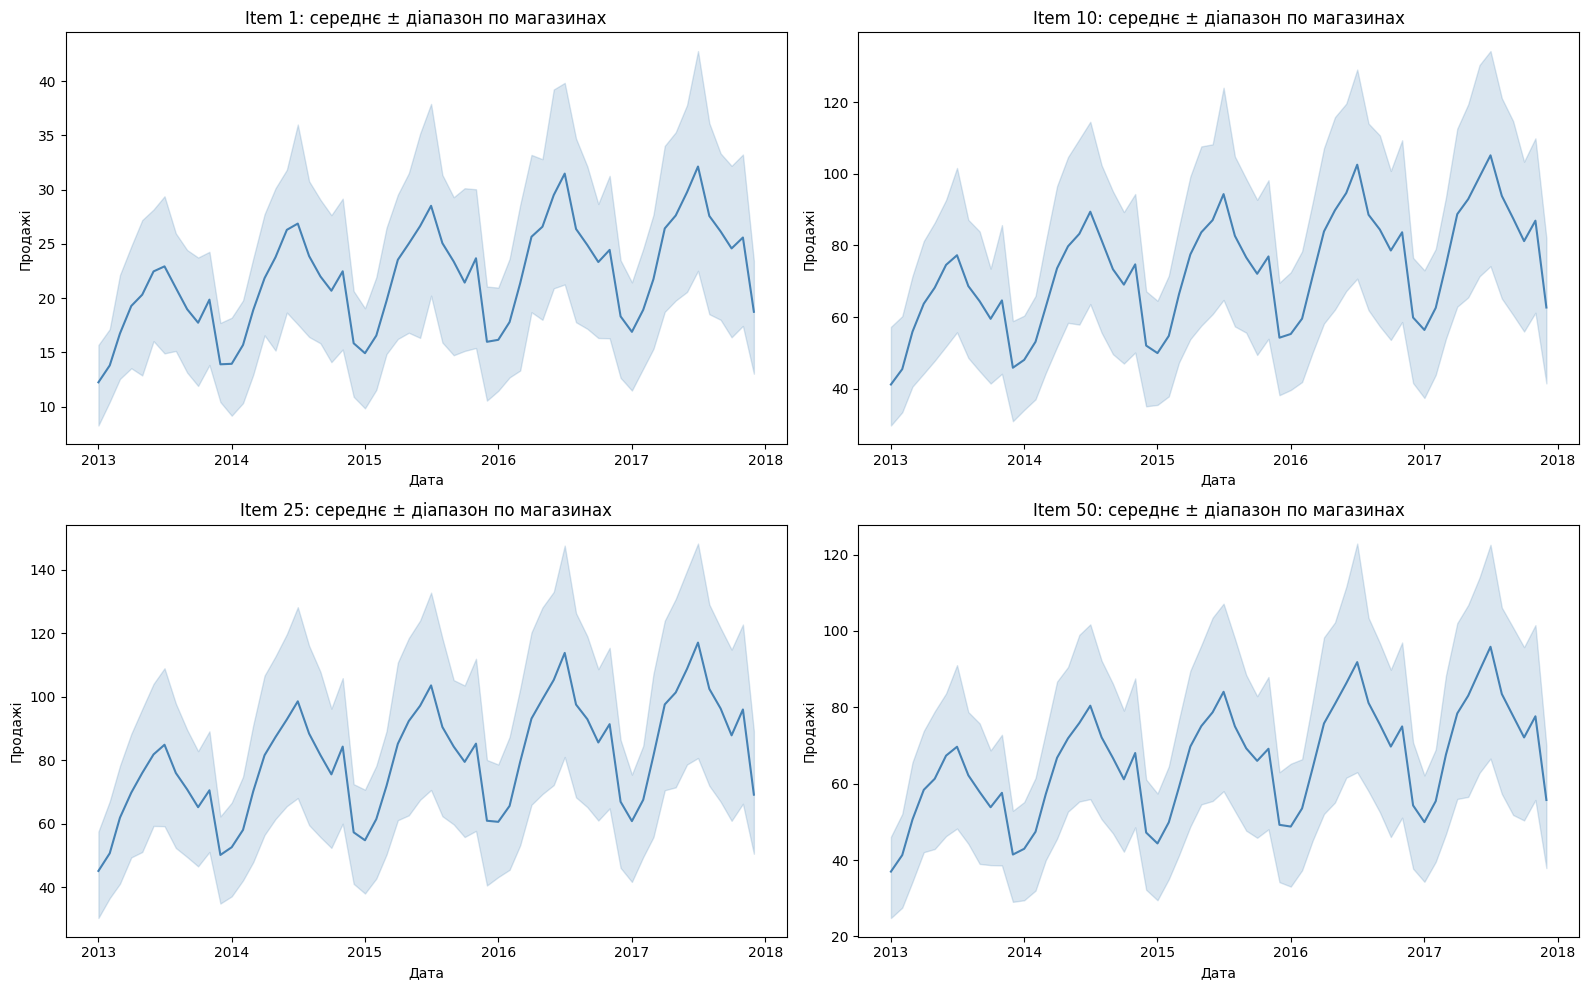

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax_idx, item_id in enumerate(sample_items):
    df_item = df_monthly[df_monthly['item'] == item_id]
    df_item_monthly = df_item.groupby(['month', 'store'])['sales'].mean().reset_index()
    sns.lineplot(
        data=df_item_monthly,
        x='month', y='sales',
        estimator='mean',
        errorbar=('pi', 100),
        ax=axes[ax_idx],
        color='steelblue'
    )
    axes[ax_idx].set_title(f'Item {item_id}: середнє ± діапазон по магазинах')
    axes[ax_idx].set_xlabel('Дата')
    axes[ax_idx].set_ylabel('Продажі')

plt.tight_layout()
plt.show()

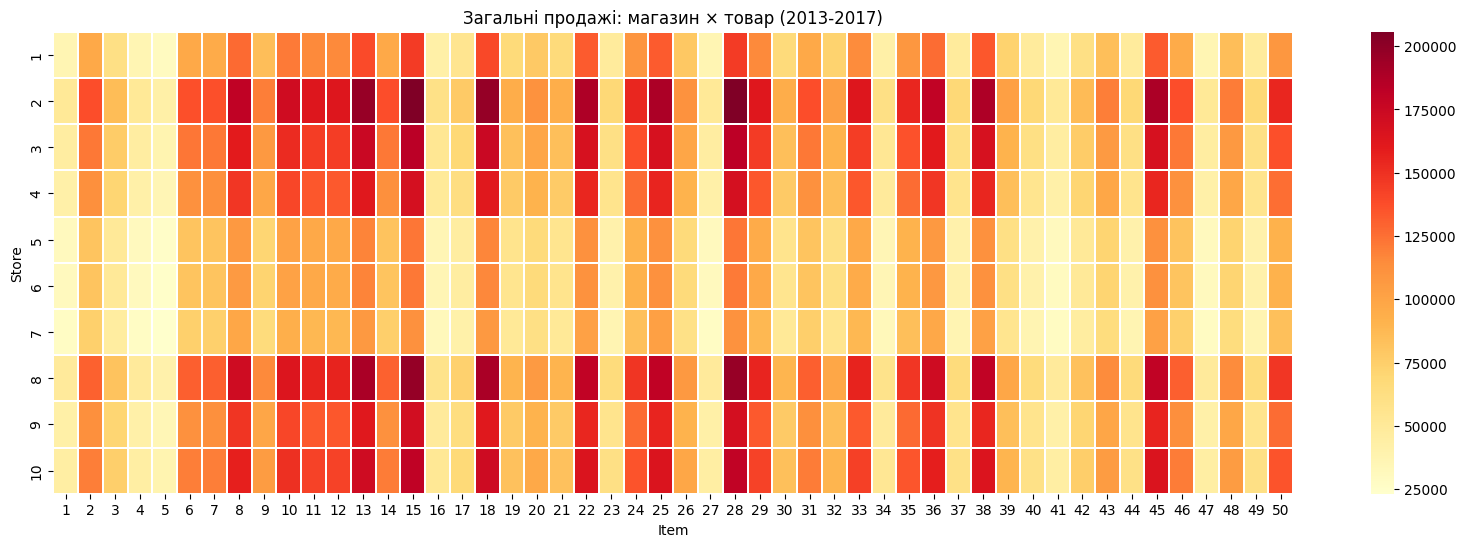

In [10]:
df_total = df.reset_index().groupby(['store', 'item'])['sales'].sum().reset_index()
df_pivot = df_total.pivot(index='store', columns='item', values='sales')

plt.figure(figsize=(20, 6))
sns.heatmap(df_pivot, cmap='YlOrRd', linewidths=0.3)
plt.title('Загальні продажі: магазин × товар (2013-2017)')
plt.xlabel('Item')
plt.ylabel('Store')
plt.show()

**Висновок:**
1. Всі товари демонструють виражену річну сезонність з піком у літні місяці.
2. Динаміка продажів кожного товару дуже схожа між різними магазинами — відрізняється лише масштаб (амплітуда), а не форма тренду/сезонності.
3. Деякі магазини стабільно продають більше, деякі менше, але патерн однаковий.
4. Це означає, що одна модель може бути застосована до інших з масштабуванням.

## 3 Analysing only 1

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [11]:
# Фільтрація даних для store=1, item=1
df_s1i1 = df[(df['store'] == 1) & (df['item'] == 1)][['sales']]
print(f'Розмір підмножини: {df_s1i1.shape}')
display(df_s1i1.head())

Розмір підмножини: (1826, 1)


,sales
date,
2013-01-01,13
2013-01-02,11
2013-01-03,14
2013-01-04,13
2013-01-05,10


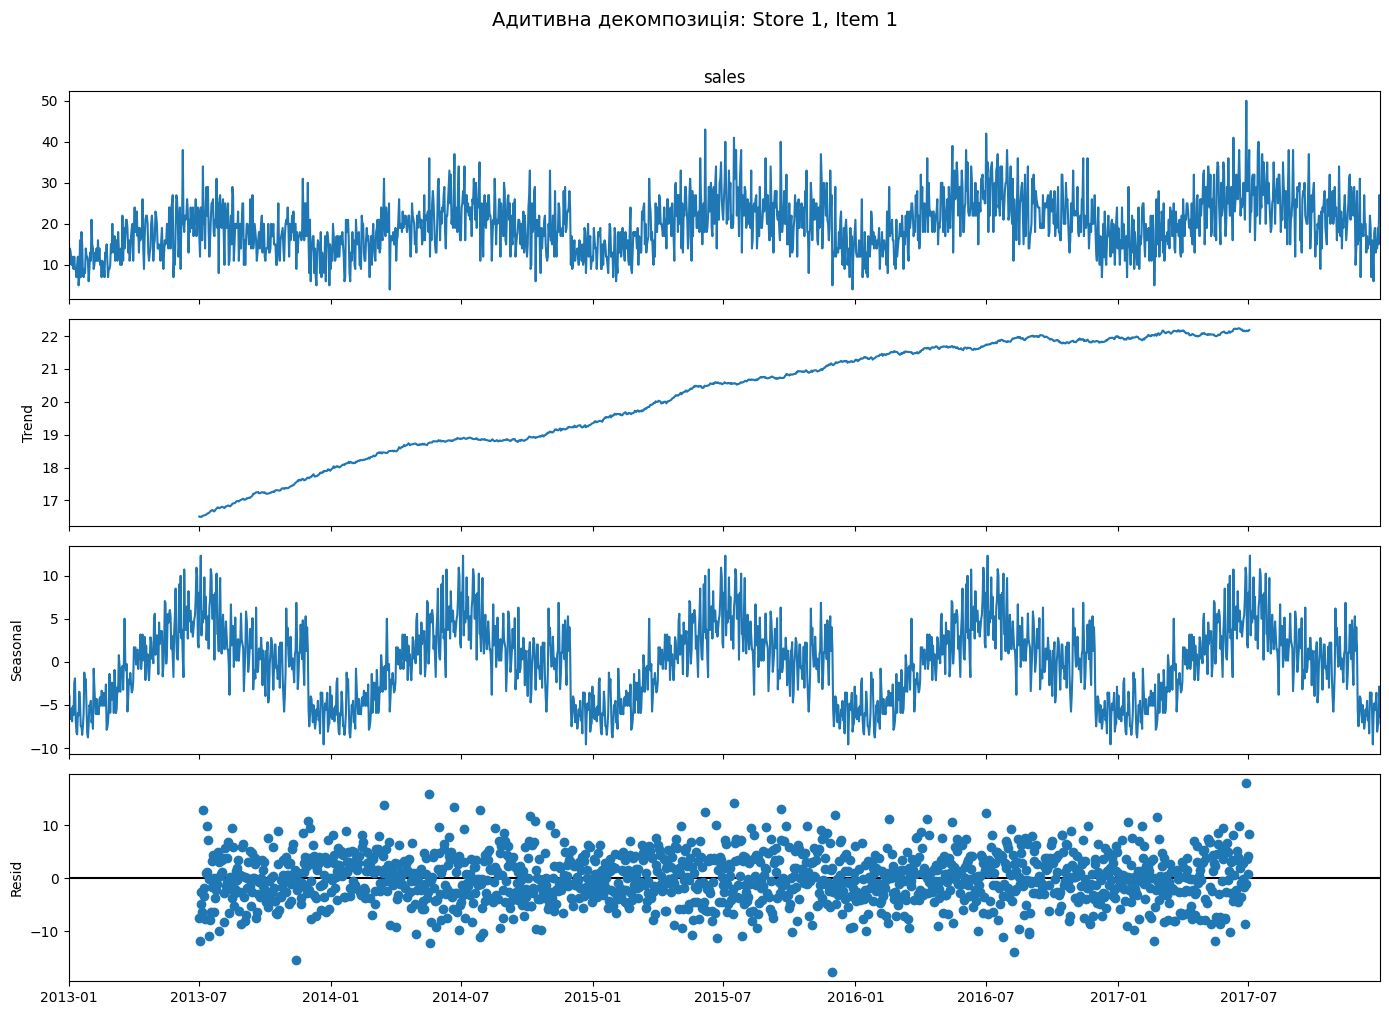

In [12]:
# Адитивна декомпозиція (period=365 для річної сезонності)
decomposition = seasonal_decompose(df_s1i1['sales'], model='additive', period=365)
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Адитивна декомпозиція: Store 1, Item 1', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Висновок:**
1. Тренд показує поступове зростання продажів протягом 5 років.
2. Сезонна компонента чітко демонструє річний цикл з піками влітку.
3. Залишки мають велику варіативність — пов'язано з щоденними коливаннями.
4. Згладжування ряду (тижневе середнє) допомогло б краще побачити тренд.

## 4 TimeSeries object in darts

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

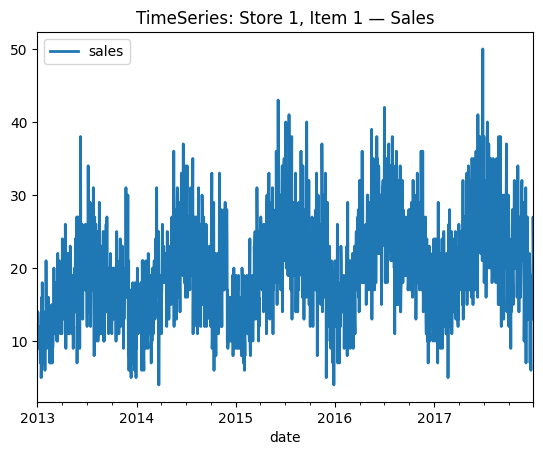

In [13]:
series = TimeSeries.from_dataframe(df_s1i1, value_cols='sales')
series.plot()
plt.title('TimeSeries: Store 1, Item 1 — Sales')
plt.show()

In [14]:
print(f'Довжина ряду: {len(series)}')
print(f'Частота: {series.freq}')
print(f'Початок: {series.start_time()}, Кінець: {series.end_time()}')

Довжина ряду: 1826
Частота: <Day>
Початок: 2013-01-01 00:00:00, Кінець: 2017-12-31 00:00:00


## 5 Splitting to Train and Val

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

In [15]:
# Розбиття на тренування і валідацію
train, val = series.split_before(pd.Timestamp('2017-10-01'))

In [16]:
print(f'Тренувальна вибірка: {len(train)} днів')
print(f'Валідаційна вибірка: {len(val)} днів')

Тренувальна вибірка: 1734 днів
Валідаційна вибірка: 92 днів


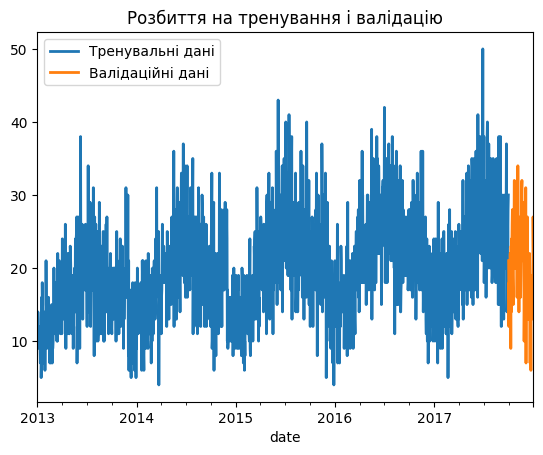

In [17]:
train.plot(label='Тренувальні дані')
val.plot(label='Валідаційні дані')
plt.title('Розбиття на тренування і валідацію')
plt.legend()
plt.show()

## 6 Autocorr (PACF)

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

<Figure size 1200x500 with 0 Axes>

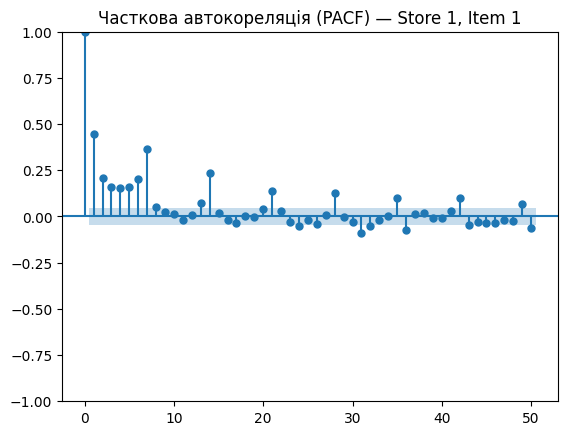

In [18]:
# Часткова автокореляційна функція (PACF)
plt.figure(figsize=(12, 5))
plot_pacf(df_s1i1['sales'], lags=50, method='ywm')
plt.title('Часткова автокореляція (PACF) — Store 1, Item 1')
plt.show()

**Висновок:**
1. Найсильніший лаг lag 1 (вчорашні продажі найбільше впливають на сьогоднішні).
2. Лаг 7 також значущий - тижнева сезонність.
3. Для моделей ARIMA варто розглядати p >= 7, аби вловити тижневу компоненту.

## 7 check_seasonality

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [19]:
print('Виявлені сезонності:')
for m in range(2, 400):
    is_seasonal, period = check_seasonality(train, m=m, alpha=0.05, max_lag=len(train) - 1)
    if is_seasonal:
        print(f'  Сезонність порядку {period}')

Виявлені сезонності:
  Сезонність порядку 7
  Сезонність порядку 14
  Сезонність порядку 21
  Сезонність порядку 28
  Сезонність порядку 35
  Сезонність порядку 42
  Сезонність порядку 49
  Сезонність порядку 56
  Сезонність порядку 63
  Сезонність порядку 70
  Сезонність порядку 74
  Сезонність порядку 77
  Сезонність порядку 84
  Сезонність порядку 91
  Сезонність порядку 98
  Сезонність порядку 105
  Сезонність порядку 112
  Сезонність порядку 119
  Сезонність порядку 126
  Сезонність порядку 133
  Сезонність порядку 147
  Сезонність порядку 217
  Сезонність порядку 224
  Сезонність порядку 231
  Сезонність порядку 238
  Сезонність порядку 245
  Сезонність порядку 252
  Сезонність порядку 259
  Сезонність порядку 266
  Сезонність порядку 273
  Сезонність порядку 280
  Сезонність порядку 287
  Сезонність порядку 294
  Сезонність порядку 301
  Сезонність порядку 308
  Сезонність порядку 315
  Сезонність порядку 322
  Сезонність порядку 329
  Сезонність порядку 336
  Сезонність порядку

## 8 NaiveSeasonal + NaieDrift

8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

In [20]:
# Наївна сезонна модель (K=7 — тижнева сезонність)
seasonal_model = NaiveSeasonal(K=7)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(len(val))
seasonal_forecast

,sales
date,
2017-10-01,24.0
2017-10-02,14.0
2017-10-03,18.0
2017-10-04,27.0
2017-10-05,23.0
...,...
2017-12-27,27.0
2017-12-28,23.0
2017-12-29,28.0


In [21]:
# Наївна модель з дрифтом
drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(len(val))
drift_forecast

,sales
date,
2017-10-01,30.009810
2017-10-02,30.019619
2017-10-03,30.029429
2017-10-04,30.039238
2017-10-05,30.049048
...,...
2017-12-27,30.863243
2017-12-28,30.873053
2017-12-29,30.882862


In [22]:
# Комбіноване передбачення: сезонність + дрифт
combined_forecast = drift_forecast + seasonal_forecast - train.last_value()
combined_forecast

,sales
date,
2017-10-01,24.009810
2017-10-02,14.019619
2017-10-03,18.029429
2017-10-04,27.039238
2017-10-05,23.049048
...,...
2017-12-27,27.863243
2017-12-28,23.873053
2017-12-29,28.882862


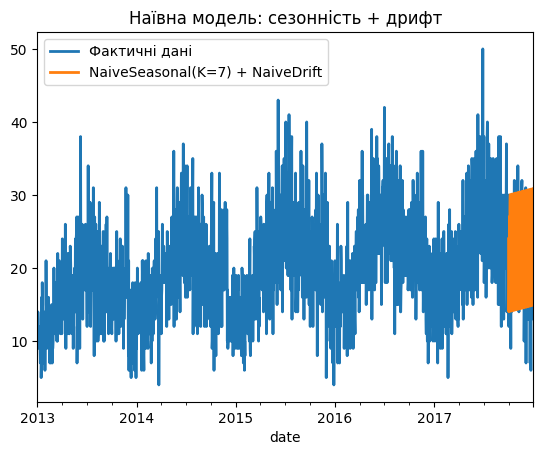

In [23]:
series.plot(label='Фактичні дані')
combined_forecast.plot(label='NaiveSeasonal(K=7) + NaiveDrift')
plt.title('Наївна модель: сезонність + дрифт')
plt.legend()
plt.show()

**Висновок:**
1. наївна модель копіює патерн останнього тижня і додає лінійний дрифт.
-> базова лінія для порівняння з більш складними моделями.

## 9 MAPE

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [24]:
# MAPE для наївної моделі
naive_mape = mape(val, combined_forecast)
print(f'MAPE наївної моделі (NaiveSeasonal + NaiveDrift): {naive_mape:.2f}%')

MAPE наївної моделі (NaiveSeasonal + NaiveDrift): 39.91%


In [25]:
results = {'NaiveSeasonal+Drift': naive_mape}

In [26]:
def eval_forecast(model_name, val, forecast):
    m = mape(val, forecast)
    results[model_name] = m
    print(f'MAPE для {model_name}: {m:.2f}%')
    return m

def plot_results(series, forecast, model_name):
    series.plot(label='Фактичні дані')
    forecast.plot(label=f'Прогноз ({model_name})', color='red')
    plt.title(f'Прогноз: {model_name}')
    plt.legend()
    plt.show()

## 10 XBGModel з darts

10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [27]:
# XGBoost модель з лагами та ознаками з дати
model_xgb = XGBModel(
    lags=14,
    output_chunk_length=len(val),
    add_encoders={
        'cyclic': {'future': ['dayofweek', 'month']},
        'datetime_attribute': {'future': ['dayofyear', 'year']},
    },
)
model_xgb

XGBModel(lags=14, lags_past_covariates=None, lags_future_covariates=None, output_chunk_length=92, output_chunk_shift=0, add_encoders={'cyclic': {'future': ['dayofweek', 'month']}, 'datetime_attribute': {'future': ['dayofyear', 'year']}}, likelihood=None, quantiles=None, random_state=None, multi_models=True, use_static_covariates=True)

In [28]:
model_xgb.fit(train)
forecast_xgb = model_xgb.predict(len(val))

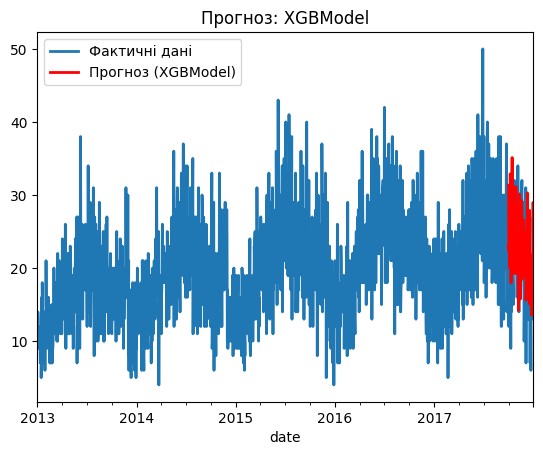

In [29]:
plot_results(series, forecast_xgb, 'XGBModel')

In [30]:
eval_forecast('XGBModel', val, forecast_xgb)

MAPE для XGBModel: 33.06%


np.float64(33.05566186902853)

**Висновок:**
1. XGBoost з лагами 14 і ознаками з дати (день тижня, місяць, день року) дав MAPE ~33%, краще за наївну модель (\~40%).
2. Модель добре вловлює тижневу сезонність завдяки лагам, але не враховує річну сезонність так виразно, як Prophet.
3. XGBoost є хорошою практичною альтернативою — швидко тренується та масштабується на 500 рядів.

## 11 ExponentialSmoothing

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

In [31]:
model_es = ExponentialSmoothing()
model_es.fit(train)
forecast_es = model_es.predict(len(val))

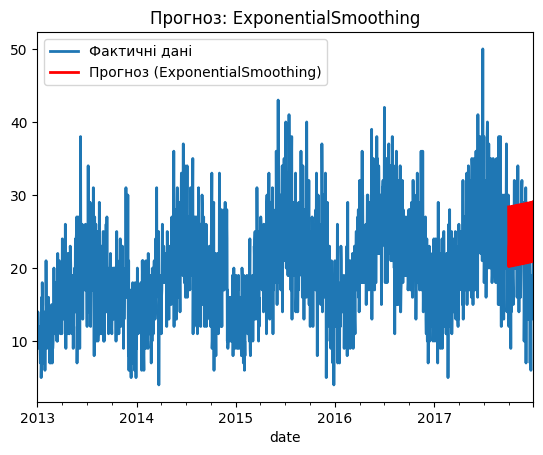

In [32]:
plot_results(series, forecast_es, 'ExponentialSmoothing')

In [33]:
eval_forecast('ExponentialSmoothing', val, forecast_es)

MAPE для ExponentialSmoothing: 39.01%


np.float64(39.00856138800186)

**Висновок:**
1. ExponentialSmoothing дав MAPE ~39%
2. Модель погано справляється з довгостроковим прогнозом (92 дні): після кількох кроків прогноз сходиться до сталого рівня і втрачає сезонну динаміку.
3. Для короткострокового прогнозу (1–7 днів) ES може бути корисною, але для місячного горизонту вона поступається Prophet та XGBoost.

## 12 ARIMA

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

In [34]:
# ARIMA з параметрами на основі PACF: p=7 (тижневий лаг), d=1, q=1
model_arima = ARIMA(p=7, d=1, q=1)
model_arima.fit(train)
forecast_arima = model_arima.predict(len(val))

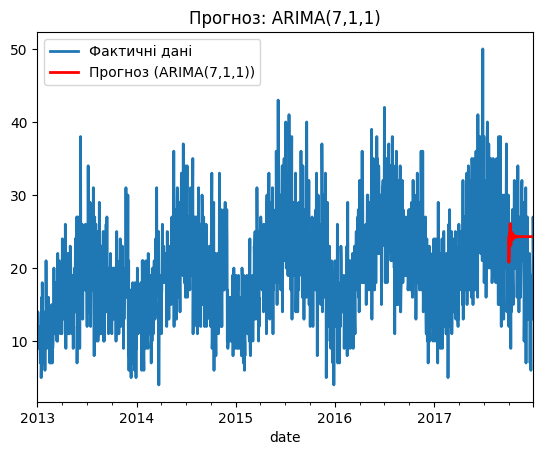

In [35]:
plot_results(series, forecast_arima, 'ARIMA(7,1,1)')

In [36]:
eval_forecast('ARIMA(7,1,1)', val, forecast_arima)

MAPE для ARIMA(7,1,1): 39.53%


np.float64(39.52818300569095)

**Висновок:**
1. ARIMA(7,1,1) з параметрами, обраними на основі PACF (p=7 для тижневого лагу), дав MAPE ~39.5%.
2. Модель враховує тижневу залежність, але не моделює річну сезонність явно.

## 13 AutoARIMA

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

In [42]:
model_auto_arima = AutoARIMA(
    start_p=1, max_p=14,
    start_q=0, max_q=3,
    seasonal=True
)
model_auto_arima.fit(train)

AutoARIMA(add_encoders=None, quantiles=None, random_state=None, start_p=1, max_p=14, start_q=0, max_q=3, seasonal=True)

In [43]:
print('Оптимальна модель AutoARIMA:')
display(model_auto_arima)

Оптимальна модель AutoARIMA:


AutoARIMA(add_encoders=None, quantiles=None, random_state=None, start_p=1, max_p=14, start_q=0, max_q=3, seasonal=True)

In [47]:
# Виводимо реально підібрані параметри (p,d,q)
_arma = model_auto_arima.model.model_['arma']
p, q, P, Q, m, d, D = _arma
print(f'Оптимальні параметри: ARIMA({p},{d},{q})({P},{D},{Q})[{m}]')
print(f'AIC: {model_auto_arima.model.model_["aic"]:.2f}, BIC: {model_auto_arima.model.model_["bic"]:.2f}')


Оптимальні параметри: ARIMA(5,1,2)(0,0,0)[1]
AIC: 10686.13, BIC: 10729.80


In [49]:
forecast_auto = model_auto_arima.predict(len(val))

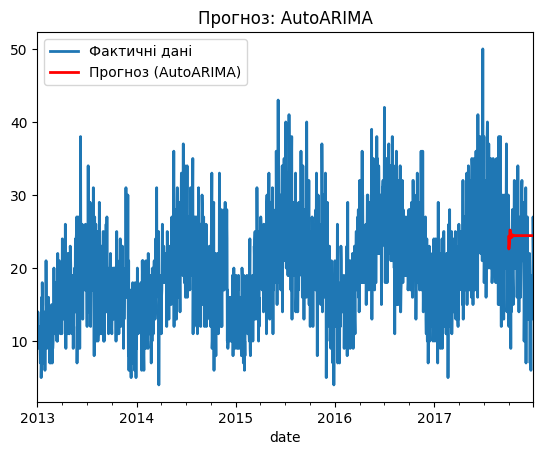

In [50]:
plot_results(series, forecast_auto, 'AutoARIMA')

In [51]:
eval_forecast('AutoARIMA', val, forecast_auto)

MAPE для AutoARIMA: 40.29%


np.float64(40.294072271660795)

In [52]:
# Порівняння з ручною ARIMA
print(f'Порівняння:')
print(f'  ARIMA(7,1,1) MAPE: {results.get("ARIMA(7,1,1)", "N/A")}')
print(f'  AutoARIMA MAPE:    {results["AutoARIMA"]:.2f}%')

Порівняння:
  ARIMA(7,1,1) MAPE: 39.52818300569095
  AutoARIMA MAPE:    40.29%


## 14 Prophet

14. Натренуйте модель Prophet та зробіть висновок про її якість.

In [53]:
model_prophet = Prophet()
model_prophet.fit(train)
forecast_prophet = model_prophet.predict(len(val))

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


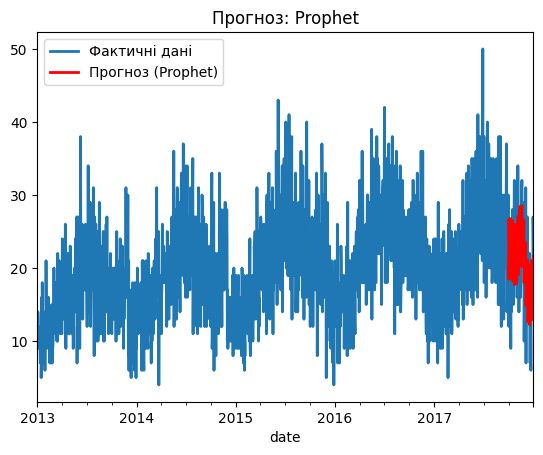

In [54]:
plot_results(series, forecast_prophet, 'Prophet')

In [55]:
eval_forecast('Prophet', val, forecast_prophet)

MAPE для Prophet: 23.80%


np.float64(23.804832095755977)

**Висновок:**
1. Prophet показав найкращий результат серед усіх моделей: MAPE ~23.8%.
2. Модель автоматично виявляє річну та тижневу сезонність і добре екстраполює тренд зростання.
3. Важливо: daily_seasonality була вимкнена автоматично (мало даних в добовому розрізі) — можна увімкнути через Prophet(daily_seasonality=True) і перевірити ефект.
4. Prophet є найкращим вибором для цього одиничного ряду завдяки інтерпретованості та якості.

## 15 RNNModel

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

In [56]:
# Масштабування даних для RNN
scaler = Scaler()
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)

In [57]:
model_rnn = RNNModel(
    model='LSTM',
    input_chunk_length=30,
    training_length=60,
    n_epochs=50,
    batch_size=32,
    random_state=42,
    pl_trainer_kwargs={'accelerator': 'cpu'},
)
model_rnn.fit(train_scaled)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │  2.8 K │ train │     0 │
│ 6 │ V               │ Linear           │     26 │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 2.8 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


RNNModel(model=LSTM, hidden_dim=25, n_rnn_layers=1, dropout=0.0, training_length=60, input_chunk_length=30, n_epochs=50, batch_size=32, random_state=42, pl_trainer_kwargs={'accelerator': 'cpu'})

In [58]:
# Прогнозування і зворотне масштабування
forecast_rnn_scaled = model_rnn.predict(len(val_scaled))
forecast_rnn = scaler.inverse_transform(forecast_rnn_scaled)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

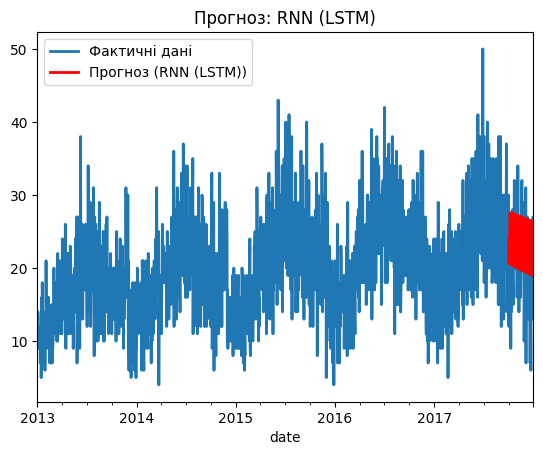

In [59]:
plot_results(series, forecast_rnn, 'RNN (LSTM)')

In [60]:
eval_forecast('RNN (LSTM)', val, forecast_rnn)

MAPE для RNN (LSTM): 33.62%


np.float64(33.61642481232268)

**Висновок:**
1. LSTM дав MAPE ~33.6% — результат на рівні XGBoost, але значно гірший за Prophet.
2. Масштабування даних (Scaler) застосовано коректно.
3. 50 епох і input_chunk_length=30 — базова конфігурація; результат може покращитись з більшою кількістю епох або більшим вікном вхідних даних.
4. LSTM потребує значно більше часу на тренування порівняно з Prophet чи XGBoost, при цьому не перевершує їх на цьому наборі даних.

## 16 backtest_mape

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

In [61]:
# Зведена таблиця результатів
print('=== Результати всіх моделей ===')
for name, m_val in sorted(results.items(), key=lambda x: x[1]):
    print(f'  {name:30s} MAPE: {m_val:.2f}%')

best_name = min(results, key=results.get)
print(f'\nНайкраща модель: {best_name} (MAPE: {results[best_name]:.2f}%)')

=== Результати всіх моделей ===
  Prophet                        MAPE: 23.80%
  XGBModel                       MAPE: 33.06%
  RNN (LSTM)                     MAPE: 33.62%
  ExponentialSmoothing           MAPE: 39.01%
  ARIMA(7,1,1)                   MAPE: 39.53%
  NaiveSeasonal+Drift            MAPE: 39.91%
  AutoARIMA                      MAPE: 40.29%

Найкраща модель: Prophet (MAPE: 23.80%)


In [62]:
models = {
    'XGBModel': model_xgb,
    'ExponentialSmoothing': model_es,
    'ARIMA(7,1,1)': model_arima,
    'AutoARIMA': model_auto_arima,
    'Prophet': model_prophet,
    'RNN (LSTM)': model_rnn,
}
best_model = models[best_name]

hfc_params = {
    'series': series,
    'start': pd.Timestamp('2017-01-01'),
    'forecast_horizon': 30,
    'verbose': True,
}

historical_fcast = best_model.historical_forecasts(
    last_points_only=True,
    **hfc_params
)

historical forecasts: 100%|██████████| 336/336 [01:54<00:00,  2.93it/s]


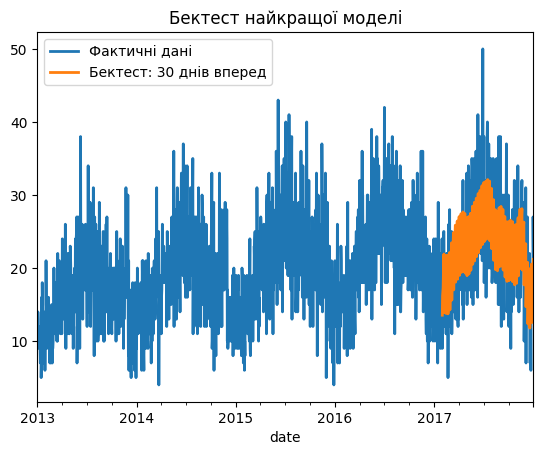

In [63]:
series.plot(label='Фактичні дані')
historical_fcast.plot(label=f'Бектест: 30 днів вперед')
plt.title(f'Бектест найкращої моделі')
plt.legend()
plt.show()

In [64]:
backtest_mape = mape(series, historical_fcast)
print(f'\nMAPE бектесту: {backtest_mape:.2f}%')


MAPE бектесту: 20.37%


Всю варіантивність не вгадали, але виглядає непогано!

## 17 Approach

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

**Підхід до прогнозування 50 айтемів х 10 магазинів = 500 рядів:**

Prophet показала найкращу якість (MAPE ~24%), вона справляється з річною та тижневою сезонністю, не потребує масштабування та налаштування лагів.

1. 500 окремих моделей (один ряд → одна модель).
   - ➕ кожна модель ловить специфіку конкретної пари (store, item).
   - ➖ довге тренування, не використовує спільну інформацію між рядами.

2. Одна глобальна модель (наприклад, `XGBModel` / `RNNModel` з darts на multiple series).
   - ➕ одна модель навчається на всіх 500 рядах одночасно -> швидше і узагальнює патерни.
   - ➕ `static_covariates` (store_id, item_id) допоможуть розрізняти ряди.
   - ➖  може втратити локальну специфіку, потребує масштабування.

3. Гібрид: 50 моделей по айтему (агрегуючи магазини як коваріати) або 1 модель на айтем з масштабуванням.
   - На основі візуалізацій з пункту 2: динаміка одного товару подібна між магазинами, відрізняється лише амплітуда -> можна тренувати модель на одному магазині й масштабувати для інших.

Можливо, глобальна `XGBModel` /`LightGBMModel` з darts на всіх 500 рядах, з ознаками з дати (`add_encoders`) та статичними коваріатами `store`, `item`. Бо
- Швидке тренування та інференс на всіх рядах.
- Дерева добре працюють з категоріальними `store`/`item`.
- Шейринг патернів між рядами підвищує якість для рідкісних комбінацій.
- Prophet найкращий на одному ряді, але запуск 500 разів буде повільним і не використовує крос-серійну інформацію.

Перевірити це варто на бектесті 1 рік x 1 місяць горизонт, як у пункті 16, та порівняти з baseline (Prophet per-series для кількох випадково вибраних пар).